# Supplement Sales Analyst Backtest

This notebook establishes a cutoff-safe, analyst-only benchmark for weekly supplement demand. It compares an optional structured agent forecast with offline baselines across rolling origins, then audits error, probabilistic interval coverage, and horizon behavior.

Web search is intentionally excluded here. Add it later as a separate A/B arm after this analyst-only strategy has a trustworthy baseline.

## 1. Experiment design

- Product: one independently modeled product, configurable below.
- Forecast: four weekly horizons from each historical origin.
- Evaluation: rolling origins with a minimum historical window, rather than one holdout.
- Rolling baselines: last value and same-week-last-year seasonal naive.
- Imported comparison: recorded ARIMA, AutoARIMA, Prophet, LightGBM, and Last Value results from `01_baseline_models.ipynb` for the same product and cutoff.
- Agent: cutoff-scoped product history plus derived statistics; disabled by default to keep this notebook runnable without model calls.
- Metrics: MAE, RMSE, sMAPE, a three-point CRPS approximation, interval coverage, and interval width.

In [1]:
import json
import warnings
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import properscoring as ps
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.features import StaticFrameAdapter, canonical_three_col
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods.agentic import AgentPredictor, ContinuousAgentForecastOutput
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, CodeExecutionConfig, ContextRetrievalConfig
from aieng.forecasting.models import LITE_MODEL
from dotenv import load_dotenv
from IPython.display import display
from pydantic import BaseModel

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

In [2]:
DATA_PATH = Path("Supplement_Sales_Weekly_Expanded.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("implementations/supplement_sales/Supplement_Sales_Weekly_Expanded.csv")

PRODUCT_NAME = "Whey Protein"
HORIZON_WEEKS = 4
HISTORY_WEEKS = 52
ORIGIN_STEP_WEEKS = 4
MAX_ORIGINS = 8
RUN_AGENT = True
AGENT_MODEL = LITE_MODEL  # higher capability and cost

DATE_COL = "Date"
PRODUCT_COL = "Product Name"
TARGET_COL = "Units Sold"
NUMERIC_CONTEXT = ["Price", "Revenue", "Discount", "Units Returned"]

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = Path("../..").resolve()
load_dotenv(ROOT / ".env", override=False), 

sales = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
if TARGET_COL not in sales.columns:
    TARGET_COL = "Unit Sold"
if TARGET_COL not in sales.columns:
    raise ValueError("The dataset must contain Units Sold or Unit Sold.")

if PRODUCT_NAME not in set(sales[PRODUCT_COL].dropna()):
    raise ValueError(f"Unknown PRODUCT_NAME={PRODUCT_NAME!r}")

product_data = (
    sales.loc[sales[PRODUCT_COL] == PRODUCT_NAME]
    .sort_values(DATE_COL)
    .set_index(DATE_COL)
)
available_dates = pd.DatetimeIndex(product_data.index.drop_duplicates().sort_values())
product_data = product_data.reindex(available_dates)
if product_data[TARGET_COL].isna().any():
    raise ValueError("The selected product has missing weekly observations.")

print(f"Product: {PRODUCT_NAME}")
print(f"Date range: {available_dates.min().date()} to {available_dates.max().date()}")
print(f"Rows: {len(product_data)} | RUN_AGENT={RUN_AGENT}")
display(product_data.tail())

Product: Whey Protein
Date range: 2020-01-06 to 2025-03-31
Rows: 274 | RUN_AGENT=True


,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
Date,,,,,,,,,
2025-03-03,Whey Protein,Protein,160,27.080,"4,332.800",0.250,3,Canada,iHerb
2025-03-10,Whey Protein,Protein,140,24.030,"3,364.200",0.100,2,UK,Amazon
2025-03-17,Whey Protein,Protein,166,10.070,"1,671.620",0.090,3,Canada,iHerb
2025-03-24,Whey Protein,Protein,158,18.500,"2,923.000",0.020,0,UK,Amazon
2025-03-31,Whey Protein,Protein,148,15.170,"2,245.160",0.070,1,UK,Amazon


In [3]:
SERIES_ID = f"supplement_sales_{PRODUCT_NAME.lower().replace(' ', '_')}"

series_frame = product_data[[TARGET_COL]].reset_index().rename(
    columns={DATE_COL: "timestamp", TARGET_COL: "value"}
)
series_frame["released_at"] = series_frame["timestamp"]
series_frame = canonical_three_col(series_frame)

service = DataService()
service.register(
    SERIES_ID,
    StaticFrameAdapter(series_frame),
    SeriesMetadata(
        series_id=SERIES_ID,
        description=f"Weekly units sold for {PRODUCT_NAME}",
        source=str(DATA_PATH),
        units="units sold",
        frequency="W-MON",
    ),
)

task = ForecastingTask(
    task_id=f"{SERIES_ID}_analyst_backtest",
    target_series_id=SERIES_ID,
    horizons=list(range(1, HORIZON_WEEKS + 1)),
    frequency="W-MON",
    description=f"Forecast weekly units sold for {PRODUCT_NAME}.",
)

origin_positions = range(HISTORY_WEEKS - 1, len(available_dates) - HORIZON_WEEKS, ORIGIN_STEP_WEEKS)
origin_dates = list(available_dates[list(origin_positions)][-MAX_ORIGINS:])
print(f"Origins: {len(origin_dates)} | first={origin_dates[0].date()} | last={origin_dates[-1].date()}")

probe_context = service.context(as_of=origin_dates[0])
visible = probe_context.get_series(SERIES_ID)
assert pd.Timestamp(visible["timestamp"].max()) == origin_dates[0]
print(f"Cutoff probe: {len(visible)} rows visible, latest={visible['timestamp'].max().date()}")

Origins: 8 | first=2024-08-05 | last=2025-02-17
Cutoff probe: 240 rows visible, latest=2024-08-05


## 2. Build the analyst prompt

The prompt includes derived evidence rather than asking the model to infer everything from a long CSV. All statistics are computed from rows visible at the forecast origin.

In [4]:
class SupplementAnalystPromptBuilder(BaseModel):
    history_weeks: int = HISTORY_WEEKS

    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context) -> str:
        visible_target = context.get_series(task.target_series_id).tail(self.history_weeks)
        cutoff = pd.Timestamp(context.as_of)
        rows = product_data.loc[product_data.index <= cutoff].tail(self.history_weeks).copy()
        values = rows[TARGET_COL].astype(float)
        recent = values.tail(min(12, len(values)))
        trend_window = values.tail(min(12, len(values)))
        trend_slope = float(np.polyfit(np.arange(len(trend_window)), trend_window, 1)[0]) if len(trend_window) > 1 else 0.0
        rows["week_of_year"] = rows.index.isocalendar().week.astype(int).to_numpy()
        latest_week = int(cutoff.isocalendar().week)
        same_week = rows.loc[rows["week_of_year"] == latest_week, TARGET_COL].astype(float)
        payload: dict[str, Any] = {
            "task": task.task_id,
            "product_name": PRODUCT_NAME,
            "category": str(rows["Category"].iloc[-1]),
            "as_of": str(cutoff.date()),
            "horizons_weeks": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "target_summary": {
                "last_units_sold": float(visible_target["value"].iloc[-1]),
                "recent_mean_12": float(recent.mean()),
                "recent_std_12": float(recent.std(ddof=1) or 0.0),
                "history_mean": float(values.mean()),
                "history_std": float(values.std(ddof=1) or 0.0),
                "recent_trend_units_per_week": trend_slope,
                "same_week_mean": float(same_week.mean()) if not same_week.empty else None,
                "same_week_observations": int(len(same_week)),
            },
            "recent_history_csv": rows[[TARGET_COL, *NUMERIC_CONTEXT]].to_csv(float_format="%.4f"),
            "context_note": (
                "Only observations on or before as_of are available. Future price, discounts,"
                " promotions, revenue, and returns are unknown. Do not treat historical"
                " context values as known future inputs; state assumptions explicitly."
            ),
        }
        return json.dumps(payload, indent=2)


class ForecastPromptWrapper:
    def __init__(self, inner: Callable[..., str]):
        self.inner = inner
        self.schema = ContinuousAgentForecastOutput.prompt_schema_json()

    def __call__(self, *, task: ForecastingTask, context) -> str:
        payload = json.loads(self.inner(task=task, context=context))
        payload["instructions"] = (
            "Produce exactly one forecast for every horizon in horizons_weeks. Use only information"
            " available on or before as_of. Use exactly standard_quantiles, make quantiles"
            " non-decreasing, make point_forecast equal the 0.50 quantile, keep units sold"
            " non-negative, and widen uncertainty appropriately with horizon. Return the exact"
            " output_schema by calling set_model_response with a json_response string."
        )
        payload["output_schema"] = self.schema
        return json.dumps(payload, indent=2)


prompt_builder = ForecastPromptWrapper(SupplementAnalystPromptBuilder())
preview = prompt_builder(task=task, context=probe_context)
Path("supplement_sales_analyst_prompt_preview.txt").write_text(preview, encoding="utf-8")
print("Saved full prompt to supplement_sales_analyst_prompt_preview.txt")

Saved full prompt to supplement_sales_analyst_prompt_preview.txt


In [5]:
agent_config = AgentConfig(
    name="supplement_sales_analyst_no_search",
    model=AGENT_MODEL,
    instruction=(
        "You are a careful supplement-retail demand analyst. Use the supplied cutoff-safe"
        " history and derived statistics. Reason from level, trend, volatility, and any"
        " supported seasonal pattern. Do not invent future observations or external facts."
    ),
    context_retrieval=ContextRetrievalConfig(enabled=False),
    code_execution=CodeExecutionConfig(enabled=False),
)

agent_predictor = AgentPredictor(
    agent_config=agent_config,
    prompt_builder=prompt_builder,
    output_schema=ContinuousAgentForecastOutput,
)
print(f"Agent configured: {agent_config.name} | RUN_AGENT={RUN_AGENT}")

Agent configured: supplement_sales_analyst_no_search | RUN_AGENT=True


## 3. Rolling-origin comparison

The baseline intervals use a simple historical residual scale. They are diagnostic intervals, not calibrated production distributions.

In [6]:
def metric_row(actual: float, point: float, lower: float, upper: float, model: str, origin: pd.Timestamp, horizon: int, forecast_date: pd.Timestamp) -> dict[str, Any]:
    return {
        "Model": model,
        "Origin": origin,
        "Horizon": horizon,
        "Forecast date": forecast_date,
        "Actual": actual,
        "Point forecast": point,
        "P05": lower,
        "P95": upper,
        "Absolute error": abs(actual - point),
        "Covered": lower <= actual <= upper,
        "Interval width": upper - lower,
    }


rows: list[dict[str, Any]] = []
analyst_audit_rows: list[dict[str, Any]] = []
if RUN_AGENT:
    print("Agent calls enabled; this may take several minutes and incur proxy costs.")
else:
    print("RUN_AGENT=False: analyst predictions and rationale audit are disabled.")

for origin in origin_dates:
    context = service.context(as_of=origin)
    history = product_data.loc[product_data.index <= origin][TARGET_COL].astype(float)
    residual_scale = float(history.diff().dropna().std() or history.std() or 1.0)
    for horizon in task.horizons:
        forecast_date = origin + pd.Timedelta(weeks=horizon)
        if forecast_date not in product_data.index:
            continue
        actual = float(product_data.loc[forecast_date, TARGET_COL])
        last_value = float(history.iloc[-1])
        last_scale = 1.645 * residual_scale * np.sqrt(horizon)
        rows.append(metric_row(actual, last_value, max(0.0, last_value - last_scale), last_value + last_scale, "Last Value", origin, horizon, forecast_date))
        seasonal_date = origin - pd.DateOffset(weeks=52) + pd.Timedelta(weeks=horizon)
        seasonal_point = float(product_data.loc[seasonal_date, TARGET_COL]) if seasonal_date in product_data.index else last_value
        seasonal_scale = 1.645 * residual_scale * np.sqrt(horizon)
        rows.append(metric_row(actual, seasonal_point, max(0.0, seasonal_point - seasonal_scale), seasonal_point + seasonal_scale, "Seasonal naive", origin, horizon, forecast_date))
    if RUN_AGENT:
        predictions = agent_predictor.predict(task, context)
        for horizon, prediction in zip(task.horizons, predictions, strict=True):
            forecast = prediction.payload
            forecast_date = pd.Timestamp(prediction.forecast_date)
            metadata = dict(prediction.metadata)
            analyst_audit_rows.append(
                {
                    "Origin": origin,
                    "Horizon": horizon,
                    "Forecast date": forecast_date,
                    "Rationale": metadata.get("horizon_rationale") or metadata.get("rationale", ""),
                    "Trace URL": metadata.get("langfuse_trace_url"),
                    "Trace ID": metadata.get("langfuse_trace_id"),
                }
            )
            if forecast_date not in product_data.index:
                continue
            actual = float(product_data.loc[forecast_date, TARGET_COL])
            rows.append(metric_row(actual, float(forecast.point_forecast), float(forecast.quantiles[0.05]), float(forecast.quantiles[0.95]), "Analyst agent", origin, horizon, forecast_date))

forecast_frame = pd.DataFrame(rows)
forecast_frame["CRPS approx"] = np.nan
for index, row in forecast_frame.iterrows():
    scale = max((row["P95"] - row["P05"]) / 3.29, 1e-6)
    ensemble = np.array([max(0.0, row["Point forecast"] - scale), row["Point forecast"], row["Point forecast"] + scale])
    forecast_frame.loc[index, "CRPS approx"] = ps.crps_ensemble(row["Actual"], ensemble)

analyst_audit = pd.DataFrame(analyst_audit_rows)
analyst_audit_path = Path("supplement_sales_analyst_audit.json").resolve()
analyst_audit_path.write_text(analyst_audit.to_json(orient="records", indent=2, date_format="iso"), encoding="utf-8")
display(analyst_audit)
print(f"Analyst audit written to: {analyst_audit_path}")
print(f"Analyst forecast calls recorded: {len(analyst_audit)}")
display(forecast_frame.head())
print(f"Scored rows: {len(forecast_frame)}")

Agent calls enabled; this may take several minutes and incur proxy costs.


,Origin,Horizon,Forecast date,Rationale,Trace URL,Trace ID
0,2024-08-05,1,2024-08-12,"After a peak of 168 units, historical data sug...",https://us.cloud.langfuse.com/project/cmqqnhfj...,ec18fa3c342f1eb49b305a3e889531f7
1,2024-08-05,2,2024-08-19,Increased uncertainty over 2 weeks. The point ...,https://us.cloud.langfuse.com/project/cmqqnhfj...,ec18fa3c342f1eb49b305a3e889531f7
2,2024-08-05,3,2024-08-26,Further convergence to the long-term historica...,https://us.cloud.langfuse.com/project/cmqqnhfj...,ec18fa3c342f1eb49b305a3e889531f7
3,2024-08-05,4,2024-09-02,Assumes a return to the recent 12-week average...,https://us.cloud.langfuse.com/project/cmqqnhfj...,ec18fa3c342f1eb49b305a3e889531f7
4,2024-09-02,1,2024-09-09,Base forecast around the recent 12-week mean o...,https://us.cloud.langfuse.com/project/cmqqnhfj...,eed24b44de39e4d3ea88e6cbc6901da5
5,2024-09-02,2,2024-09-16,Slight upward trend adjustment based on recent...,https://us.cloud.langfuse.com/project/cmqqnhfj...,eed24b44de39e4d3ea88e6cbc6901da5
6,2024-09-02,3,2024-09-23,Continued modest growth trend incorporated; vo...,https://us.cloud.langfuse.com/project/cmqqnhfj...,eed24b44de39e4d3ea88e6cbc6901da5
7,2024-09-02,4,2024-09-30,Longest horizon reflects steady performance an...,https://us.cloud.langfuse.com/project/cmqqnhfj...,eed24b44de39e4d3ea88e6cbc6901da5
8,2024-09-30,1,2024-10-07,Base level is near 150-153 units. Recent volat...,https://us.cloud.langfuse.com/project/cmqqnhfj...,655e53f152232ad18d92dd33eceef627
9,2024-09-30,2,2024-10-14,Widening uncertainty due to horizon. Point for...,https://us.cloud.langfuse.com/project/cmqqnhfj...,655e53f152232ad18d92dd33eceef627


Analyst audit written to: /home/coder/agentic-forecasting/implementations/supplement_sales/supplement_sales_analyst_audit.json
Analyst forecast calls recorded: 32


,Model,Origin,Horizon,Forecast date,Actual,Point forecast,P05,P95,Absolute error,Covered,Interval width,CRPS approx
0,Last Value,2024-08-05,1,2024-08-12,126.000,168.000,139.442,196.558,42.000,False,57.116,34.284
1,Seasonal naive,2024-08-05,1,2024-08-12,126.000,146.000,117.442,174.558,20.000,True,57.116,12.284
2,Last Value,2024-08-05,2,2024-08-19,163.000,168.000,127.613,208.387,5.000,True,80.774,7.123
3,Seasonal naive,2024-08-05,2,2024-08-19,163.000,147.000,106.613,187.387,16.000,True,80.774,10.789
4,Last Value,2024-08-05,3,2024-08-26,165.000,168.000,118.536,217.464,3.000,True,98.928,7.682


Scored rows: 96


In [7]:
def smape(group: pd.DataFrame) -> float:
    denominator = np.maximum((group["Actual"].abs() + group["Point forecast"].abs()) / 2, 1e-8)
    return float(np.mean((group["Actual"] - group["Point forecast"]).abs() / denominator) * 100)

summary = (
    forecast_frame.groupby(["Model", "Horizon"], as_index=False)
    .apply(lambda group: pd.Series({
        "MAE": float(group["Absolute error"].mean()),
        "RMSE": float(np.sqrt(np.mean((group["Actual"] - group["Point forecast"]) ** 2))),
        "sMAPE": smape(group),
        "CRPS approx": float(group["CRPS approx"].mean()),
        "Coverage": float(group["Covered"].mean()),
        "Interval width": float(group["Interval width"].mean()),
        "N": int(len(group)),
    }), include_groups=False)
    .reset_index(drop=True)
)
display(summary.sort_values(["MAE", "Horizon"]).style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "sMAPE": "{:.2f}", "CRPS approx": "{:.2f}", "Coverage": "{:.1%}", "Interval width": "{:.2f}"}))

leaderboard = (
    summary.groupby("Model", as_index=False)[["MAE", "RMSE", "sMAPE", "CRPS approx", "Coverage", "Interval width", "N"]]
    .mean(numeric_only=True)
    .sort_values("MAE")
)
display(leaderboard.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "sMAPE": "{:.2f}", "CRPS approx": "{:.2f}", "Coverage": "{:.1%}", "Interval width": "{:.2f}"}))

,Model,Horizon,MAE,RMSE,sMAPE,CRPS approx,Coverage,Interval width,N
3,Analyst agent,4,7.12,9.00,4.58,6.55,100.0%,58.38,8.000000
6,Last Value,3,8.62,12.76,5.64,9.68,100.0%,99.80,8.000000
11,Seasonal naive,4,8.75,11.03,5.78,10.70,100.0%,115.24,8.000000
7,Last Value,4,10.25,12.00,6.51,11.20,100.0%,115.24,8.000000
1,Analyst agent,2,10.38,13.26,6.63,8.16,87.5%,44.88,8.000000
10,Seasonal naive,3,10.75,12.58,6.96,10.32,100.0%,99.80,8.000000
2,Analyst agent,3,10.88,11.76,7.23,7.58,100.0%,51.62,8.000000
5,Last Value,2,12.75,14.03,8.12,9.75,100.0%,81.49,8.000000
9,Seasonal naive,2,13.88,16.93,8.97,10.81,100.0%,81.49,8.000000
0,Analyst agent,1,15.38,17.39,10.20,11.90,50.0%,37.88,8.000000


,Model,MAE,RMSE,sMAPE,CRPS approx,Coverage,Interval width,N
0,Analyst agent,10.94,12.85,7.16,8.55,84.4%,48.19,8.000000
2,Seasonal naive,12.53,14.99,8.19,11.00,100.0%,88.54,8.000000
1,Last Value,12.59,15.44,8.14,11.23,93.8%,88.54,8.000000


Notebook 1 baseline results | product='Whey Protein' | cutoff=2024-12-30 | source=01_baseline_models.ipynb


,MAE,RMSE,MAPE,sMAPE
Model,,,,
Prophet,8.184,10.070,5.234,5.261
AutoARIMA,9.586,11.988,6.015,6.178
ARIMA,9.705,11.838,6.130,6.257
LightGBM,10.809,13.048,6.809,7.002
Last Value,23.846,26.315,14.969,16.410


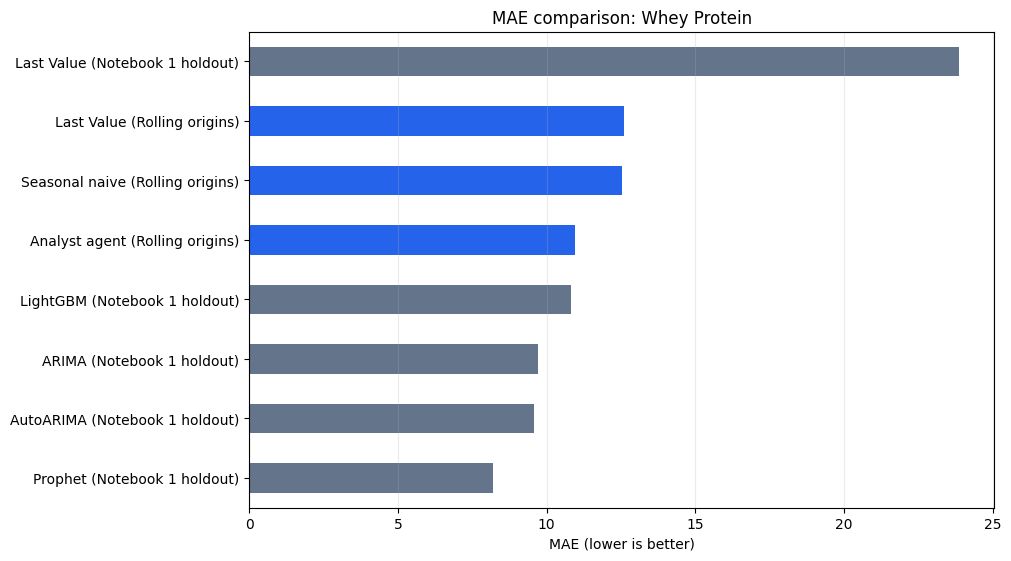

The graph combines both sources for visual comparison. Notebook 1 uses a single holdout; the agent and simple baselines use rolling origins, so the values are contextual rather than one directly comparable leaderboard.


In [8]:
NOTEBOOK_1_BASELINE_RESULTS = pd.DataFrame(
    [
        {"Model": "Prophet", "MAE": 8.184, "RMSE": 10.070, "MAPE": 5.234, "sMAPE": 5.261},
        {"Model": "AutoARIMA", "MAE": 9.586, "RMSE": 11.988, "MAPE": 6.015, "sMAPE": 6.178},
        {"Model": "ARIMA", "MAE": 9.705, "RMSE": 11.838, "MAPE": 6.130, "sMAPE": 6.257},
        {"Model": "LightGBM", "MAE": 10.809, "RMSE": 13.048, "MAPE": 6.809, "sMAPE": 7.002},
        {"Model": "Last Value", "MAE": 23.846, "RMSE": 26.315, "MAPE": 14.969, "sMAPE": 16.410},
    ]
).set_index("Model").sort_values("MAE")

print(
    "Notebook 1 baseline results | "
    f"product={PRODUCT_NAME!r} | cutoff=2024-12-30 | source=01_baseline_models.ipynb"
)
display(NOTEBOOK_1_BASELINE_RESULTS.style.format("{:.3f}"))

rolling_mae = leaderboard[["Model", "MAE"]].copy()
rolling_mae["Evaluation"] = "Rolling origins"
holdout_mae = NOTEBOOK_1_BASELINE_RESULTS[["MAE"]].reset_index()
holdout_mae["Evaluation"] = "Notebook 1 holdout"
combined_mae = pd.concat([rolling_mae, holdout_mae], ignore_index=True)
combined_mae["Label"] = combined_mae["Model"] + " (" + combined_mae["Evaluation"] + ")"
combined_mae = combined_mae.sort_values("MAE")

colors = combined_mae["Evaluation"].map(
    {"Rolling origins": "#2563eb", "Notebook 1 holdout": "#64748b"}
)
fig, ax = plt.subplots(figsize=(10, 5.5), layout="constrained")
combined_mae.set_index("Label")["MAE"].plot.barh(ax=ax, color=colors.tolist())
ax.set_title(f"MAE comparison: {PRODUCT_NAME}")
ax.set_xlabel("MAE (lower is better)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.show()

print(
    "The graph combines both sources for visual comparison. Notebook 1 uses a single holdout; "
    "the agent and simple baselines use rolling origins, so the values are contextual rather than "
    "one directly comparable leaderboard."
)

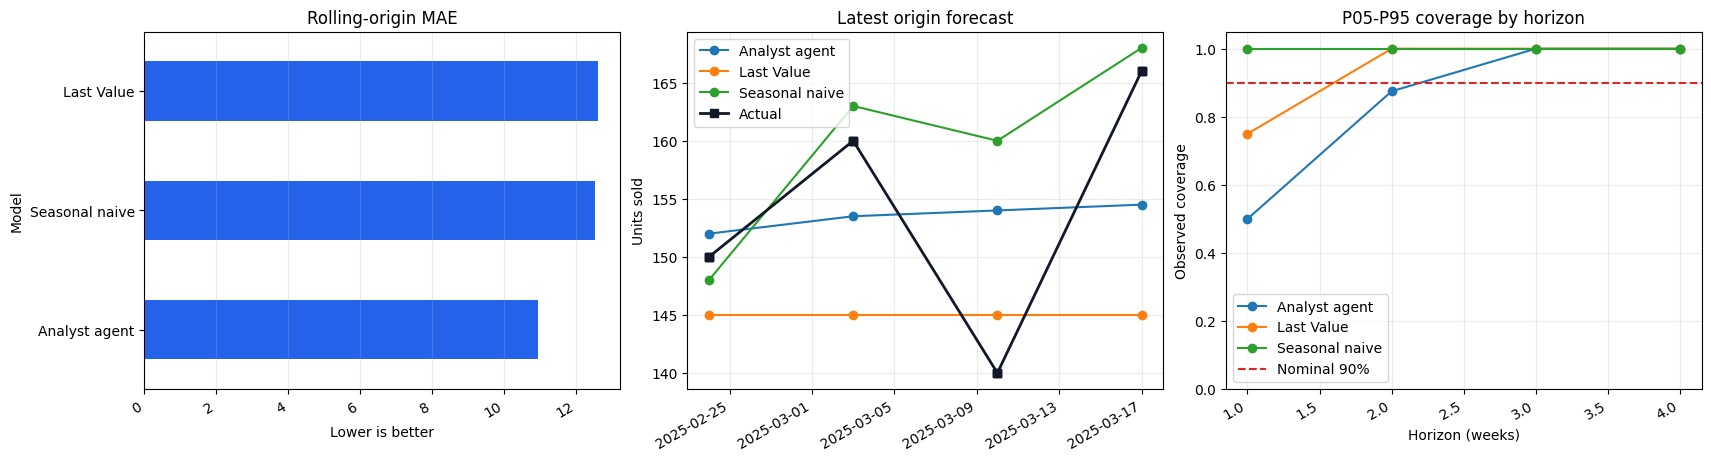

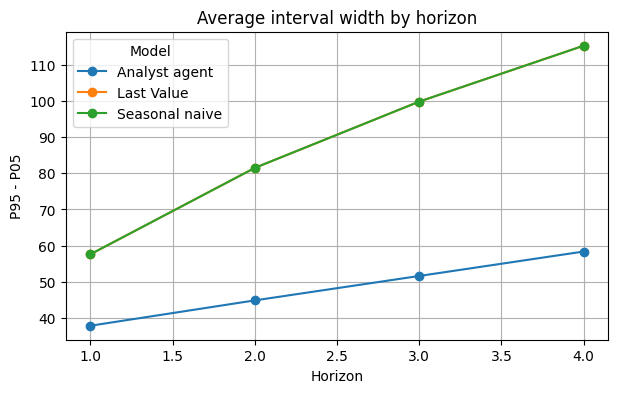

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), layout="constrained")

leaderboard.set_index("Model")["MAE"].sort_values().plot.barh(ax=axes[0], color="#2563eb")
axes[0].set_title("Rolling-origin MAE")
axes[0].set_xlabel("Lower is better")
axes[0].grid(axis="x", alpha=0.25)

for model, group in forecast_frame.groupby("Model"):
    latest_origin = group["Origin"].max()
    latest = group[group["Origin"] == latest_origin].sort_values("Horizon")
    axes[1].plot(latest["Forecast date"], latest["Point forecast"], marker="o", label=model)
actual_latest = forecast_frame[forecast_frame["Origin"] == forecast_frame["Origin"].max()].sort_values("Horizon")
axes[1].plot(actual_latest["Forecast date"], actual_latest["Actual"], color="#111827", marker="s", linewidth=2, label="Actual")
axes[1].set_title("Latest origin forecast")
axes[1].set_ylabel("Units sold")
axes[1].legend()
axes[1].grid(alpha=0.25)

coverage_plot = summary.pivot(index="Horizon", columns="Model", values="Coverage")
coverage_plot.plot(marker="o", ax=axes[2])
axes[2].axhline(0.90, color="#dc2626", linestyle="--", label="Nominal 90%")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("P05-P95 coverage by horizon")
axes[2].set_xlabel("Horizon (weeks)")
axes[2].set_ylabel("Observed coverage")
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.autofmt_xdate()
plt.show()

width_plot = summary.pivot(index="Horizon", columns="Model", values="Interval width")
width_plot.plot(marker="o", figsize=(7, 4), title="Average interval width by horizon", ylabel="P95 - P05", grid=True)
plt.show()